# **Machine learning Python**



## 1. Introduction générale

En apprentissage supervisé, on observe un échantillon d'exemples pour lesquels on connaît à la fois des variables explicatives $X$ et une variable cible $Y$. Le but est de construire une règle de prévision capable de **généraliser** correctement à de nouvelles observations.

Deux grands types de problèmes apparaissent ici :
- la **classification**, où la variable cible prend un nombre fini de classes ;
- la **régression**, où la cible est quantitative.

Le cours insiste aussi sur une distinction importante entre :
- les méthodes **paramétriques**, qui supposent une forme de modèle relativement structurée ;
- les méthodes **non paramétriques**, plus souples, mais souvent plus sensibles au bruit et à la dimension.

Les méthodes étudiées dans ce notebook reposent sur des philosophies très différentes :

### k-Nearest Neighbors

Le **kNN** est une méthode locale, non paramétrique. Elle ne construit pas de modèle explicite global : pour prédire une nouvelle observation, on cherche ses plus proches voisins dans l'échantillon d'apprentissage.
- en **classification**, la prédiction se fait par **vote majoritaire** ;
- en **régression**, la prédiction se fait par **moyenne locale**.

Le cours rappelle que la performance du kNN dépend fortement :
- de la **distance** utilisée ;
- du choix du paramètre `k` ;
- de la **normalisation** des variables.

### SVM

Le **Support Vector Machine** adopte au contraire une vision géométrique globale. En classification linéaire, on cherche un **hyperplan séparateur** qui maximise la **marge** entre les classes. Cette idée de marge est centrale dans les polys : une marge plus large améliore souvent la capacité de généralisation.

Lorsque les classes ne sont pas parfaitement séparables, on introduit une **soft margin** et un paramètre de régularisation `C`, qui contrôle le compromis entre largeur de marge et erreurs tolérées.

### SVR

Le **Support Vector Regression** transpose ces idées à la régression. L'objectif n'est plus de séparer des classes, mais d'ajuster une fonction aussi "plate" que possible, tout en tolérant des erreurs inférieures à un seuil `epsilon`. Le cours présente ce cadre comme un compromis entre :
- fidélité aux données ;
- régularisation ;
- flexibilité apportée par les noyaux.

Nous allons donc comparer dans ce notebook :
- une logique **locale par voisinage** avec `kNN` ;
- une logique **globale par marge** avec `SVM` et `SVR` ;
- puis relier les comportements observés aux notions de **biais**, **variance**, **régularisation** et **frontière de décision**.

In [1]:
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.svm import SVC, SVR
from sklearn.metrics import (
    accuracy_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    ConfusionMatrixDisplay,
)

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('deep')
pd.set_option('display.max_columns', None)

In [2]:
project_dir = Path.cwd()
if not (project_dir / 'divers').exists():
    project_dir = project_dir.parent

data_path = project_dir / 'divers' / 'healthcare_synthetic_data.csv'
data = pd.read_csv(data_path)
data.head()

,Patient_ID,Age,Gender,Height_cm,Weight_kg,BMI,Systolic_BP,Diastolic_BP,Cholesterol_Total,Cholesterol_LDL,Cholesterol_HDL,Fasting_Blood_Sugar,Smoking_Status,Alcohol_Consumption,Physical_Activity_Level,Family_History,Stress_Level,Sleep_Hours,Heart_Disease_Risk
0,PID-00001,60,0,146.9,51.3,23.8,140,89,217,151,52,83,0,1,3,0,1,8,0
1,PID-00002,53,0,161.8,76.6,29.3,128,81,203,119,38,116,0,0,1,0,7,9,0
2,PID-00003,62,1,174.7,92.4,30.3,141,100,173,124,45,90,0,0,0,0,1,7,1
3,PID-00004,73,1,173.3,68.9,22.9,136,96,193,117,45,81,0,0,1,0,2,7,1
4,PID-00005,52,1,178.6,79.8,25.0,122,80,236,153,41,79,0,1,2,0,2,6,0


## 2. Analyse exploratoire

Comme rappelé dans le poly général, une étude supervisée sérieuse commence par une phase d'exploration : dimensions, qualité des données, distributions, variables explicatives et cible.

L'objectif ici est double :
- comprendre la structure du jeu de données ;
- repérer les variables qui semblent naturellement informatives pour la classification du risque et pour la régression du LDL.

In [3]:
overview = pd.DataFrame({
    'type': data.dtypes.astype(str),
    'valeurs_manquantes': data.isna().sum(),
    'nb_modalites': data.nunique(),
})

print('Dimensions du dataset :', data.shape)
print('\nRépartition de la cible de classification :')
print((data['Heart_Disease_Risk'].value_counts(normalize=True) * 100).round(2))

overview

Dimensions du dataset : (15000, 19)

Répartition de la cible de classification :
Heart_Disease_Risk
0    56.4
1    43.6
Name: proportion, dtype: float64


,type,valeurs_manquantes,nb_modalites
Patient_ID,object,0,15000
Age,int64,0,61
Gender,int64,0,2
Height_cm,float64,0,516
Weight_kg,float64,0,817
BMI,float64,0,274
Systolic_BP,int64,0,82
Diastolic_BP,int64,0,61
Cholesterol_Total,int64,0,161
Cholesterol_LDL,int64,0,132


In [4]:
data.describe(include='all').T.head(20)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Patient_ID,15000,15000,PID-15000,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,15000.0,NaN,NaN,NaN,54.538133,11.875294,25.0,46.0,55.0,63.0,85.0
Gender,15000.0,NaN,NaN,NaN,0.491867,0.499951,0.0,0.0,0.0,1.0,1.0
Height_cm,15000.0,NaN,NaN,NaN,165.336767,9.186313,138.5,158.5,164.7,172.0,198.1
Weight_kg,15000.0,NaN,NaN,NaN,75.252573,14.110559,33.7,65.2,73.9,83.9,150.1
BMI,15000.0,NaN,NaN,NaN,27.44608,4.134953,14.5,24.5,27.2,30.0,46.1
Systolic_BP,15000.0,NaN,NaN,NaN,135.117667,11.260634,90.0,127.0,135.0,143.0,182.0
Diastolic_BP,15000.0,NaN,NaN,NaN,90.541267,8.443095,60.0,85.0,91.0,96.0,120.0
Cholesterol_Total,15000.0,NaN,NaN,NaN,216.248,22.692222,127.0,201.0,216.0,231.0,303.0
Cholesterol_LDL,15000.0,NaN,NaN,NaN,140.355267,17.914089,70.0,128.0,140.0,152.0,210.0


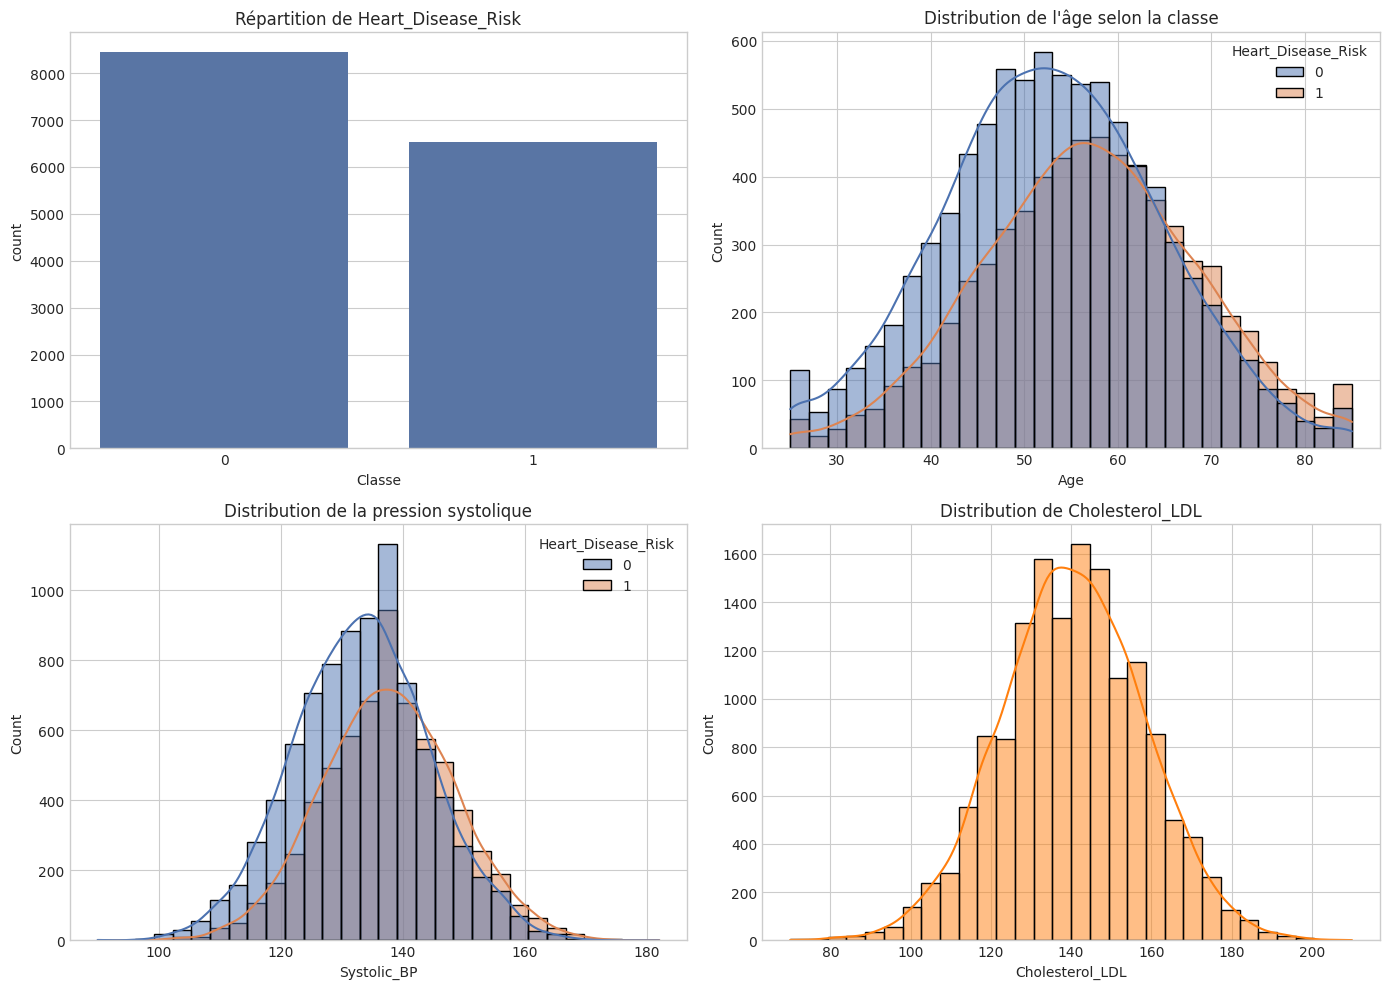

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.countplot(data=data, x='Heart_Disease_Risk', ax=axes[0, 0])
axes[0, 0].set_title('Répartition de Heart_Disease_Risk')
axes[0, 0].set_xlabel('Classe')

sns.histplot(data=data, x='Age', hue='Heart_Disease_Risk', bins=30, kde=True, ax=axes[0, 1])
axes[0, 1].set_title('Distribution de l\'âge selon la classe')

sns.histplot(data=data, x='Systolic_BP', hue='Heart_Disease_Risk', bins=30, kde=True, ax=axes[1, 0])
axes[1, 0].set_title('Distribution de la pression systolique')

sns.histplot(data=data, x='Cholesterol_LDL', bins=30, kde=True, ax=axes[1, 1], color='tab:orange')
axes[1, 1].set_title('Distribution de Cholesterol_LDL')

plt.tight_layout()
plt.show()

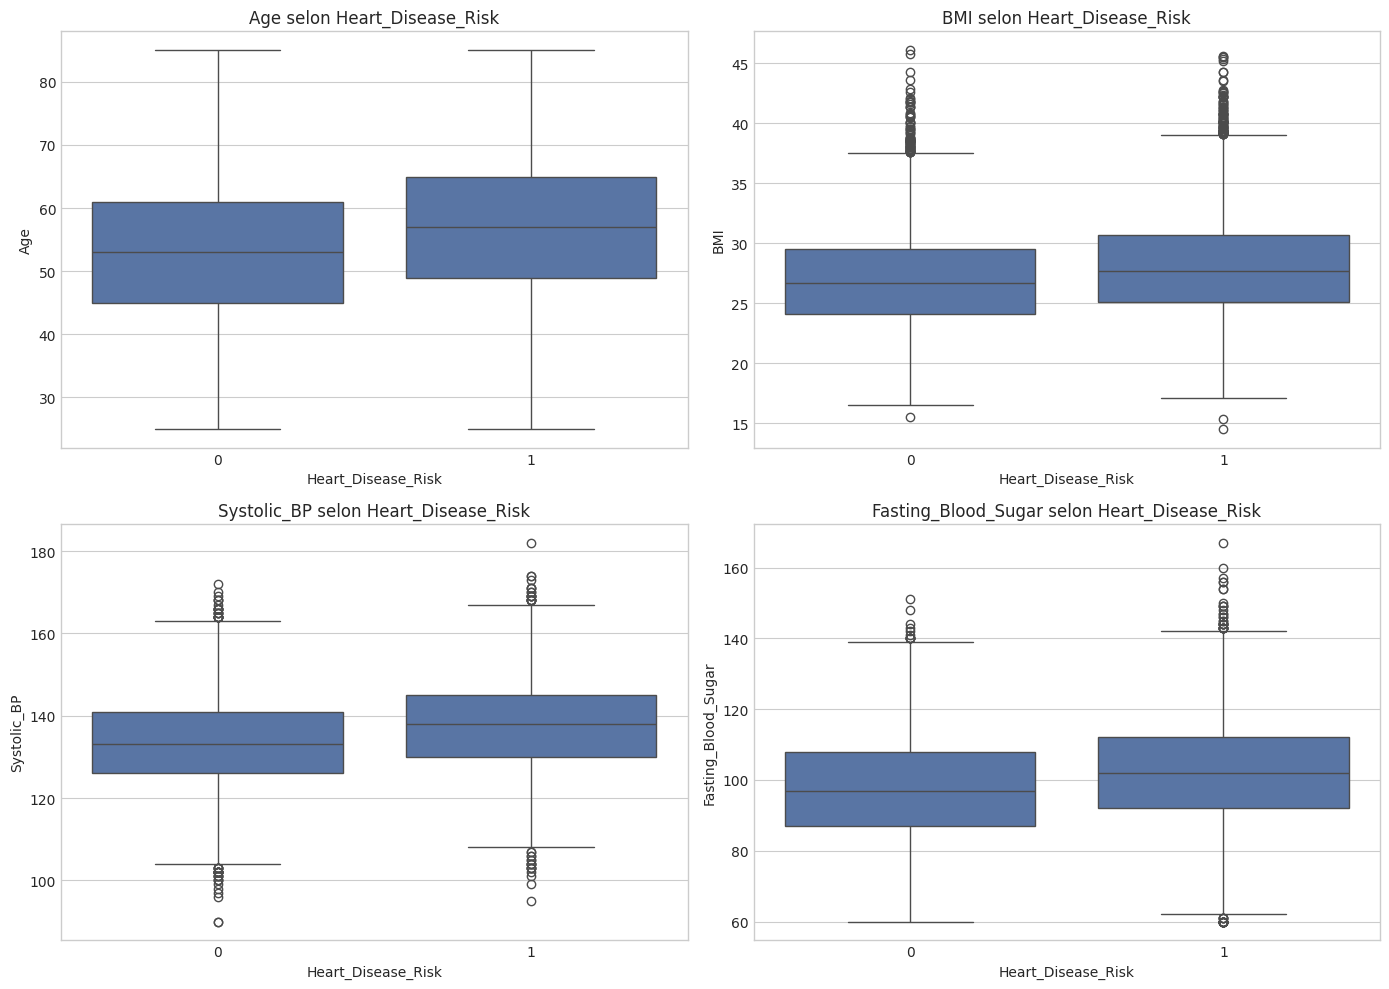

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, col in zip(
    axes.ravel(),
    ['Age', 'BMI', 'Systolic_BP', 'Fasting_Blood_Sugar'],
):
    sns.boxplot(data=data, x='Heart_Disease_Risk', y=col, ax=ax)
    ax.set_title(f'{col} selon Heart_Disease_Risk')

plt.tight_layout()
plt.show()

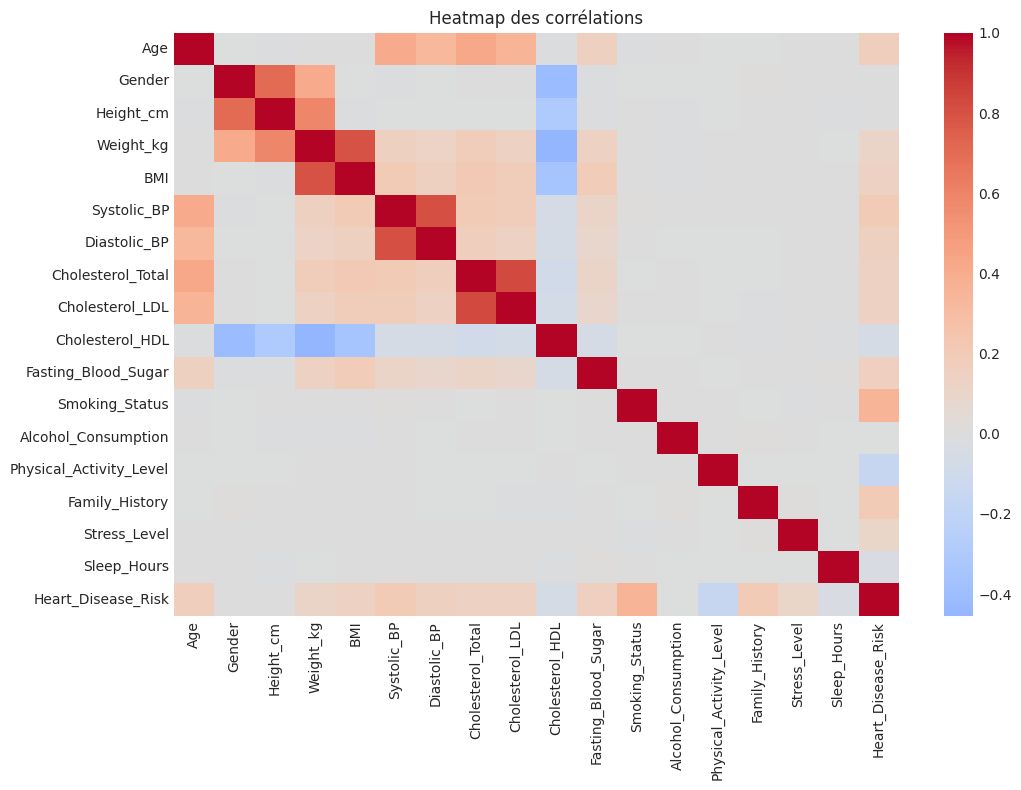

Corrélations avec Heart_Disease_Risk :


,Heart_Disease_Risk
Heart_Disease_Risk,1.000000
Smoking_Status,0.352467
Family_History,0.201332
Systolic_BP,0.194210
Age,0.168649
Fasting_Blood_Sugar,0.159159
Diastolic_BP,0.154826
Cholesterol_LDL,0.135821
Cholesterol_Total,0.134230
BMI,0.132505


Corrélations avec Cholesterol_LDL :


,Cholesterol_LDL
Cholesterol_LDL,1.000000
Cholesterol_Total,0.829747
Age,0.357199
BMI,0.176725
Systolic_BP,0.173064
Weight_kg,0.139060
Diastolic_BP,0.136783
Heart_Disease_Risk,0.135821
Fasting_Blood_Sugar,0.095452
Stress_Level,0.008160


In [7]:
corr = data.drop(columns=['Patient_ID']).corr(numeric_only=True)

plt.figure(figsize=(11, 8))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Heatmap des corrélations')
plt.tight_layout()
plt.show()

print('Corrélations avec Heart_Disease_Risk :')
display(corr['Heart_Disease_Risk'].sort_values(ascending=False).to_frame())
print('Corrélations avec Cholesterol_LDL :')
display(corr['Cholesterol_LDL'].sort_values(ascending=False).to_frame())

### Lecture de l'analyse exploratoire

Le jeu de données contient **15 000 observations** et **aucune valeur manquante**, ce qui simplifie l'étude. La cible `Heart_Disease_Risk` est modérément déséquilibrée, mais pas au point de rendre l'accuracy inutilisable.

Plusieurs variables ressortent déjà de façon cohérente avec l'intuition métier et avec les corrélations :
- `Smoking_Status`, `Family_History`, `Systolic_BP`, `Age` et `Fasting_Blood_Sugar` sont positivement liées au risque ;
- `Physical_Activity_Level` apparaît plutôt protectrice ;
- pour la régression, `Cholesterol_Total` est très lié à `Cholesterol_LDL`, ce qui est attendu.

Les distributions présentent toutefois un recouvrement important entre classes : on n'attend donc pas une frontière triviale. Cela justifie l'usage de méthodes non linéaires ou locales, mais aussi de méthodes géométriques régularisées comme les SVM.

In [8]:
data = data.drop(columns=['Patient_ID']).copy()

categorical_cols = ['Gender', 'Smoking_Status', 'Alcohol_Consumption', 'Physical_Activity_Level', 'Family_History']
quantitative_cols = [
    'Age', 'Height_cm', 'Weight_kg', 'BMI', 'Systolic_BP', 'Diastolic_BP',
    'Cholesterol_Total', 'Cholesterol_LDL', 'Cholesterol_HDL',
    'Fasting_Blood_Sugar', 'Stress_Level', 'Sleep_Hours'
]

X_cat = pd.get_dummies(data[categorical_cols], drop_first=True)
X_num = data[quantitative_cols]
X_class = pd.concat([X_cat, X_num], axis=1)
y_class = data['Heart_Disease_Risk'].astype(int)

# En régression, on retire explicitement la variable cible des prédicteurs pour éviter toute fuite d'information.
X_reg = X_class.drop(columns=['Cholesterol_LDL'])
y_reg = data['Cholesterol_LDL']

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_class,
    y_class,
    test_size=3000,
    random_state=11,
    stratify=y_class,
)

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_reg,
    y_reg,
    test_size=3000,
    random_state=11,
)

print('Classification - train/test :', Xc_train.shape, Xc_test.shape)
print('Régression - train/test :', Xr_train.shape, Xr_test.shape)

Classification - train/test : (12000, 17) (3000, 17)
Régression - train/test : (12000, 16) (3000, 16)


## 3. Préprocessing et normalisation

Le **scaling** joue un rôle central dans les méthodes étudiées ici.

### Pourquoi pour kNN ?

Le kNN repose directement sur une **distance** entre observations, souvent euclidienne. Si une variable est mesurée sur une grande échelle, elle peut dominer artificiellement la distance et rendre le voisinage peu pertinent.

### Pourquoi pour SVM / SVR ?

Les SVM et SVR sont des méthodes géométriques : la position relative des points, la norme des vecteurs et les marges dépendent de l'échelle des variables. Une mauvaise mise à l'échelle peut donc déformer la géométrie du problème et perturber le réglage de `C`, `gamma` ou `epsilon`.

On compare donc explicitement les performances avec et sans normalisation, puis on poursuivra l'étude principalement sur les données standardisées.

In [9]:
scaler_class = StandardScaler().fit(Xc_train)
Xc_train_scaled = scaler_class.transform(Xc_train)
Xc_test_scaled = scaler_class.transform(Xc_test)

scaler_reg = StandardScaler().fit(Xr_train)
Xr_train_scaled = scaler_reg.transform(Xr_train)
Xr_test_scaled = scaler_reg.transform(Xr_test)

In [10]:
scaling_rows = []

for label, Xtr, Xte in [('Sans normalisation', Xc_train, Xc_test), ('Avec normalisation', Xc_train_scaled, Xc_test_scaled)]:
    model = KNeighborsClassifier(n_neighbors=19)
    model.fit(Xtr, yc_train)
    scaling_rows.append({
        'Tâche': 'Classification kNN',
        'Prétraitement': label,
        'Score train': round(model.score(Xtr, yc_train), 4),
        'Score test': round(model.score(Xte, yc_test), 4),
    })

for label, Xtr, Xte in [('Sans normalisation', Xc_train, Xc_test), ('Avec normalisation', Xc_train_scaled, Xc_test_scaled)]:
    model = SVC(kernel='linear', C=1)
    model.fit(Xtr, yc_train)
    scaling_rows.append({
        'Tâche': 'Classification SVM linéaire',
        'Prétraitement': label,
        'Score train': round(model.score(Xtr, yc_train), 4),
        'Score test': round(model.score(Xte, yc_test), 4),
    })

for label, Xtr, Xte in [('Sans normalisation', Xr_train, Xr_test), ('Avec normalisation', Xr_train_scaled, Xr_test_scaled)]:
    model = KNeighborsRegressor(n_neighbors=19)
    model.fit(Xtr, yr_train)
    pred = model.predict(Xte)
    scaling_rows.append({
        'Tâche': 'Régression kNN',
        'Prétraitement': label,
        'RMSE test': round(mean_squared_error(yr_test, pred) ** 0.5, 3),
        'R2 test': round(r2_score(yr_test, pred), 4),
    })

for label, Xtr, Xte in [('Sans normalisation', Xr_train, Xr_test), ('Avec normalisation', Xr_train_scaled, Xr_test_scaled)]:
    model = SVR(kernel='linear', C=1, epsilon=1)
    model.fit(Xtr, yr_train)
    pred = model.predict(Xte)
    scaling_rows.append({
        'Tâche': 'Régression SVR linéaire',
        'Prétraitement': label,
        'RMSE test': round(mean_squared_error(yr_test, pred) ** 0.5, 3),
        'R2 test': round(r2_score(yr_test, pred), 4),
    })

pd.DataFrame(scaling_rows)

,Tâche,Prétraitement,Score train,Score test,RMSE test,R2 test
0,Classification kNN,Sans normalisation,0.6523,0.6053,NaN,NaN
1,Classification kNN,Avec normalisation,0.7445,0.7303,NaN,NaN
2,Classification SVM linéaire,Sans normalisation,0.7363,0.7470,NaN,NaN
3,Classification SVM linéaire,Avec normalisation,0.7291,0.7427,NaN,NaN
4,Régression kNN,Sans normalisation,NaN,NaN,10.547,0.6502
5,Régression kNN,Avec normalisation,NaN,NaN,12.432,0.5140
6,Régression SVR linéaire,Sans normalisation,NaN,NaN,10.166,0.6751
7,Régression SVR linéaire,Avec normalisation,NaN,NaN,10.167,0.6750


Dans la partie classification, la normalisation améliore nettement le kNN, ce qui confirme bien le point de cours : sans mise à l'échelle, la distance euclidienne perd une grande partie de son sens. Pour les méthodes à marge, l'effet est aussi sensible car la géométrie des données est modifiée.

En régression, l'effet du scaling peut être plus nuancé selon la structure des variables. Cela ne contredit pas la théorie : la normalisation reste recommandée pour les méthodes à distance et à noyau, mais elle ne garantit pas mécaniquement un gain sur toutes les cibles.

## 4. Partie kNN : classification supervisée

Le kNN repose sur une idée très simple : pour une nouvelle observation, on regarde ses `k` plus proches voisins dans l'échantillon d'apprentissage.
- en classification, la classe prédite est celle qui remporte le **vote majoritaire** ;
- plus `k` est petit, plus le modèle est flexible et sensible au bruit ;
- plus `k` est grand, plus la frontière de décision est lissée.

Le cours relie directement ce comportement au compromis **biais / variance** :
- petit `k` : faible biais, forte variance, risque de surapprentissage ;
- grand `k` : biais plus fort, variance plus faible, risque de sous-apprentissage.

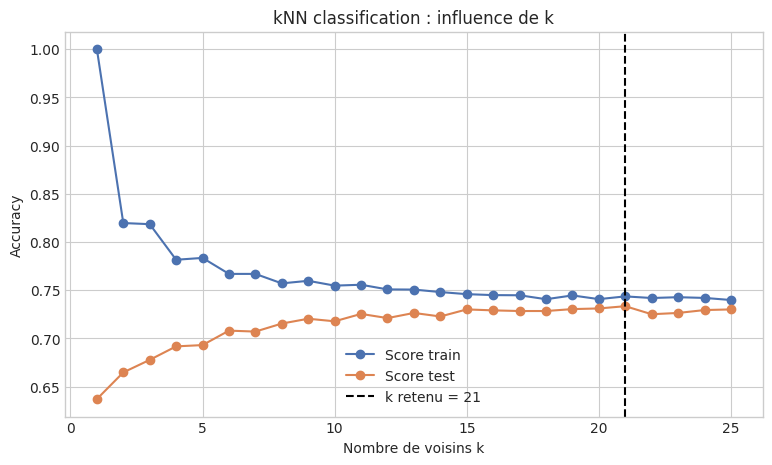

,k,score_train,score_test
0,1,1.000000,0.637000
1,2,0.819583,0.664667
2,3,0.818417,0.677667
3,4,0.781500,0.691667
4,5,0.783417,0.693000


In [11]:
knn_train_rows = []
for k in range(1, 26):
    model = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    model.fit(Xc_train_scaled, yc_train)
    knn_train_rows.append({
        'k': k,
        'score_train': model.score(Xc_train_scaled, yc_train),
        'score_test': model.score(Xc_test_scaled, yc_test),
    })

knn_class_df = pd.DataFrame(knn_train_rows)
best_k_class = int(knn_class_df.loc[knn_class_df['score_test'].idxmax(), 'k'])

plt.figure(figsize=(9, 5))
plt.plot(knn_class_df['k'], knn_class_df['score_train'], marker='o', label='Score train')
plt.plot(knn_class_df['k'], knn_class_df['score_test'], marker='o', label='Score test')
plt.axvline(best_k_class, color='black', linestyle='--', label=f'k retenu = {best_k_class}')
plt.xlabel('Nombre de voisins k')
plt.ylabel('Accuracy')
plt.title('kNN classification : influence de k')
plt.legend()
plt.show()

knn_class_df.head()

In [12]:
metric_rows = []
for metric in ['euclidean', 'manhattan']:
    for k in [5, 11, 19]:
        model = KNeighborsClassifier(n_neighbors=k, metric=metric)
        model.fit(Xc_train_scaled, yc_train)
        metric_rows.append({
            'Distance': metric,
            'k': k,
            'Score train': round(model.score(Xc_train_scaled, yc_train), 4),
            'Score test': round(model.score(Xc_test_scaled, yc_test), 4),
        })

pd.DataFrame(metric_rows)

,Distance,k,Score train,Score test
0,euclidean,5,0.7834,0.6930
1,euclidean,11,0.7556,0.7253
2,euclidean,19,0.7445,0.7303
3,manhattan,5,0.7880,0.6937
4,manhattan,11,0.7534,0.7123
5,manhattan,19,0.7454,0.7240


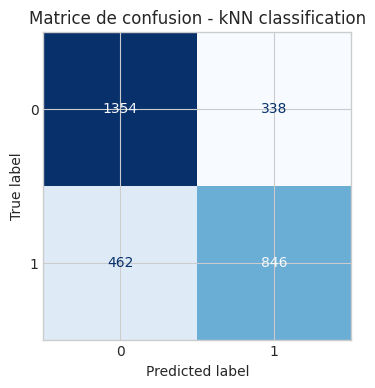

k retenu : 21
Accuracy train : 0.7435
Accuracy test : 0.7333


In [13]:
knn_class_final = KNeighborsClassifier(n_neighbors=best_k_class, metric='euclidean')
knn_class_final.fit(Xc_train_scaled, yc_train)

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_estimator(
    knn_class_final,
    Xc_test_scaled,
    yc_test,
    cmap='Blues',
    ax=ax,
    colorbar=False,
)
ax.set_title('Matrice de confusion - kNN classification')
plt.show()

print('k retenu :', best_k_class)
print('Accuracy train :', round(knn_class_final.score(Xc_train_scaled, yc_train), 4))
print('Accuracy test :', round(knn_class_final.score(Xc_test_scaled, yc_test), 4))

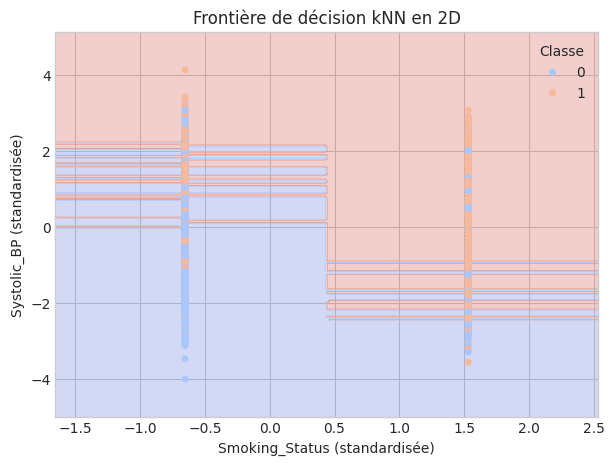

In [14]:
# Visualisation 2D pédagogique sur deux variables pour comparer des frontières simples.
feature_2d = ['Smoking_Status', 'Systolic_BP']
X2 = X_class[feature_2d]
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2,
    y_class,
    test_size=3000,
    random_state=11,
    stratify=y_class,
)
scaler_2d = StandardScaler().fit(X2_train)
X2_train_s = scaler_2d.transform(X2_train)
X2_test_s = scaler_2d.transform(X2_test)

knn_2d = KNeighborsClassifier(n_neighbors=best_k_class)
knn_2d.fit(X2_train_s, y2_train)

x_min, x_max = X2_train_s[:, 0].min() - 1, X2_train_s[:, 0].max() + 1
y_min, y_max = X2_train_s[:, 1].min() - 1, X2_train_s[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 250), np.linspace(y_min, y_max, 250))
Z = knn_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(7, 5))
plt.contourf(xx, yy, Z, alpha=0.25, cmap='coolwarm')
sns.scatterplot(x=X2_train_s[:, 0], y=X2_train_s[:, 1], hue=y2_train, palette='coolwarm', s=25, linewidth=0)
plt.title('Frontière de décision kNN en 2D')
plt.xlabel(feature_2d[0] + ' (standardisée)')
plt.ylabel(feature_2d[1] + ' (standardisée)')
plt.legend(title='Classe')
plt.show()

### Lecture des résultats kNN

La courbe train/test retrouve le comportement attendu par le cours :
- pour les petits `k`, le score train est très élevé, mais le score test est plus faible : le modèle mémorise trop localement les données ;
- lorsque `k` augmente, la frontière se lisse et la variance baisse ;
- si `k` devenait trop grand, on finirait par trop lisser et perdre de l'information locale.

La comparaison Euclidienne / Manhattan montre ici que le choix de la distance modifie effectivement le voisinage, donc la frontière de décision. La distance euclidienne reste légèrement meilleure dans cette configuration.

### Limites du kNN

Le cours souligne plusieurs limites classiques du kNN :
- coût mémoire élevé : il faut conserver l'échantillon d'apprentissage ;
- coût prédictif non négligeable : chaque nouvelle prédiction demande des calculs de distances ;
- forte sensibilité au bruit quand `k` est petit ;
- **malédiction de la dimension** : quand le nombre de variables augmente, les distances deviennent moins discriminantes et la notion de voisinage perd en pertinence.

## 5. Partie SVM : classification à marge maximale

Le SVM cherche un **hyperplan** séparateur de la forme

$$f(x) = \langle w, x \rangle + b$$

et, dans le cas linéaire, maximise la marge entre les classes. Les observations qui contraignent la solution sont les **vecteurs supports**.

Lorsque la séparation parfaite n'est pas possible, on utilise une **soft margin**. D'après le cours, cela revient à minimiser une fonction de type :

$$\frac{1}{n}\sum_i (1 - y_i f(x_i))_+ + \frac{1}{2Cn}\|w\|^2$$

Le paramètre `C` règle donc le compromis entre :
- grande marge et régularisation forte ;
- pénalisation plus sévère des erreurs d'apprentissage.

Comme les SVM à noyau peuvent être coûteux, l'étude détaillée des hyperparamètres est menée sur un **sous-échantillon d'apprentissage**. Cela garde le notebook fluide tout en conservant l'idée du TP et de la validation de modèle.

In [15]:
Xc_train_sub, _, yc_train_sub, _ = train_test_split(
    Xc_train,
    yc_train,
    train_size=4000,
    random_state=11,
    stratify=yc_train,
)

Xc_sub_fit, Xc_sub_val, yc_sub_fit, yc_sub_val = train_test_split(
    Xc_train_sub,
    yc_train_sub,
    test_size=0.25,
    random_state=11,
    stratify=yc_train_sub,
)

scaler_svm = StandardScaler().fit(Xc_sub_fit)
Xc_sub_fit_s = scaler_svm.transform(Xc_sub_fit)
Xc_sub_val_s = scaler_svm.transform(Xc_sub_val)
Xc_test_svm_s = scaler_svm.transform(Xc_test)

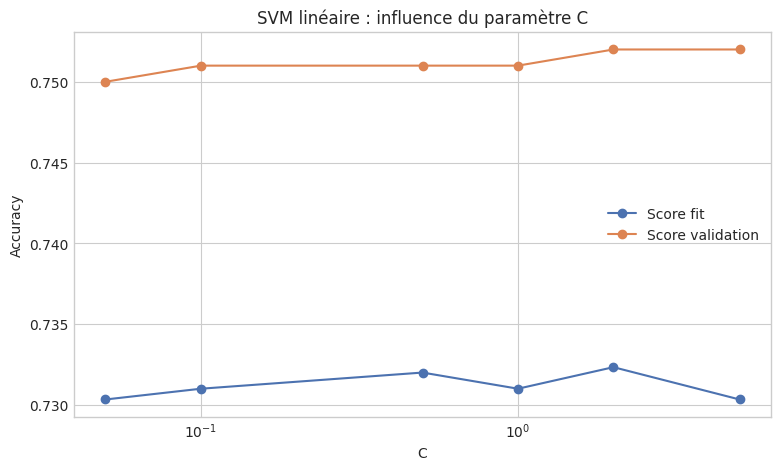

,C,score_fit,score_validation,nb_support_vectors
0,0.05,0.730333,0.750,1865
1,0.10,0.731000,0.751,1853
2,0.50,0.732000,0.751,1844
3,1.00,0.731000,0.751,1843
4,2.00,0.732333,0.752,1843
5,5.00,0.730333,0.752,1843


In [16]:
svm_c_rows = []
for C in [0.05, 0.1, 0.5, 1, 2, 5]:
    model = SVC(kernel='linear', C=C)
    model.fit(Xc_sub_fit_s, yc_sub_fit)
    svm_c_rows.append({
        'C': C,
        'score_fit': model.score(Xc_sub_fit_s, yc_sub_fit),
        'score_validation': model.score(Xc_sub_val_s, yc_sub_val),
        'nb_support_vectors': len(model.support_),
    })

svm_c_df = pd.DataFrame(svm_c_rows)
best_C = float(svm_c_df.loc[svm_c_df['score_validation'].idxmax(), 'C'])

plt.figure(figsize=(9, 5))
plt.plot(svm_c_df['C'], svm_c_df['score_fit'], marker='o', label='Score fit')
plt.plot(svm_c_df['C'], svm_c_df['score_validation'], marker='o', label='Score validation')
plt.xscale('log')
plt.xlabel('C')
plt.ylabel('Accuracy')
plt.title('SVM linéaire : influence du paramètre C')
plt.legend()
plt.show()

svm_c_df

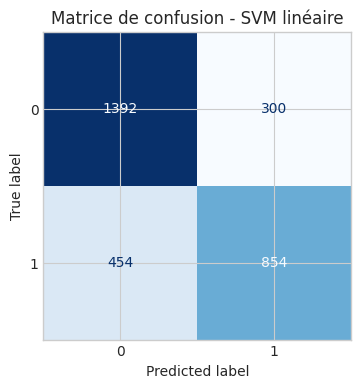

Meilleur C : 2.0
Accuracy fit : 0.7323
Accuracy validation : 0.752
Accuracy test : 0.7487
Nombre de vecteurs supports : 1843


In [17]:
svm_linear_final = SVC(kernel='linear', C=best_C)
svm_linear_final.fit(Xc_sub_fit_s, yc_sub_fit)

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_estimator(
    svm_linear_final,
    Xc_test_svm_s,
    yc_test,
    cmap='Blues',
    ax=ax,
    colorbar=False,
)
ax.set_title('Matrice de confusion - SVM linéaire')
plt.show()

print('Meilleur C :', best_C)
print('Accuracy fit :', round(svm_linear_final.score(Xc_sub_fit_s, yc_sub_fit), 4))
print('Accuracy validation :', round(svm_linear_final.score(Xc_sub_val_s, yc_sub_val), 4))
print('Accuracy test :', round(svm_linear_final.score(Xc_test_svm_s, yc_test), 4))
print('Nombre de vecteurs supports :', len(svm_linear_final.support_))

In [18]:
kernel_rows = []
kernel_configs = [
    ('linear', {'C': 1}),
    ('rbf', {'C': 1, 'gamma': 'scale'}),
    ('rbf', {'C': 2, 'gamma': 'scale'}),
    ('rbf', {'C': 1, 'gamma': 0.1}),
    ('poly', {'C': 1, 'degree': 2, 'gamma': 'scale'}),
]

for kernel, params in kernel_configs:
    model = SVC(kernel=kernel, **params)
    model.fit(Xc_sub_fit_s, yc_sub_fit)
    kernel_rows.append({
        'kernel': kernel,
        'parametres': params,
        'score_fit': round(model.score(Xc_sub_fit_s, yc_sub_fit), 4),
        'score_validation': round(model.score(Xc_sub_val_s, yc_sub_val), 4),
        'nb_support_vectors': len(model.support_),
    })

kernel_df = pd.DataFrame(kernel_rows)
kernel_df

,kernel,parametres,score_fit,score_validation,nb_support_vectors
0,linear,{'C': 1},0.7310,0.751,1843
1,rbf,"{'C': 1, 'gamma': 'scale'}",0.7807,0.728,2037
2,rbf,"{'C': 2, 'gamma': 'scale'}",0.8093,0.718,2017
3,rbf,"{'C': 1, 'gamma': 0.1}",0.8270,0.713,2186
4,poly,"{'C': 1, 'degree': 2, 'gamma': 'scale'}",0.6887,0.721,2422


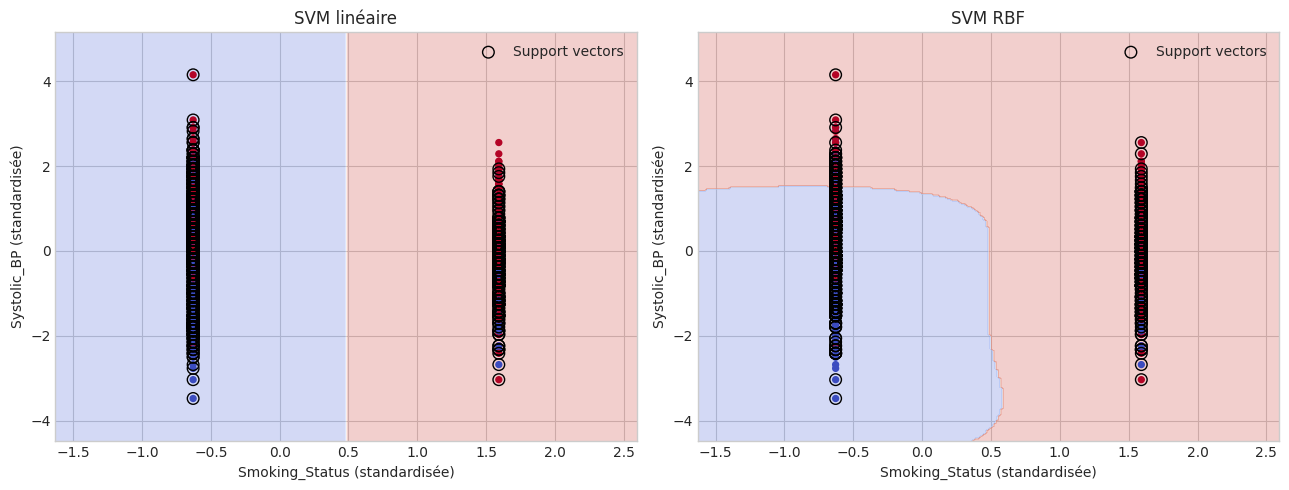

In [19]:
# Frontières de décision SVM en 2D sur les mêmes variables pédagogiques.
X2_sub, _, y2_sub, _ = train_test_split(X2_train, y2_train, train_size=2000, random_state=11, stratify=y2_train)
scaler_svm_2d = StandardScaler().fit(X2_sub)
X2_sub_s = scaler_svm_2d.transform(X2_sub)

svm_lin_2d = SVC(kernel='linear', C=1)
svm_rbf_2d = SVC(kernel='rbf', C=1, gamma='scale')
svm_lin_2d.fit(X2_sub_s, y2_sub)
svm_rbf_2d.fit(X2_sub_s, y2_sub)

xx, yy = np.meshgrid(np.linspace(X2_sub_s[:, 0].min()-1, X2_sub_s[:, 0].max()+1, 250), np.linspace(X2_sub_s[:, 1].min()-1, X2_sub_s[:, 1].max()+1, 250))
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, model, title in zip(
    axes,
    [svm_lin_2d, svm_rbf_2d],
    ['SVM linéaire', 'SVM RBF'],
):
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.25, cmap='coolwarm')
    ax.scatter(X2_sub_s[:, 0], X2_sub_s[:, 1], c=y2_sub, cmap='coolwarm', s=18)
    sv = model.support_vectors_
    ax.scatter(sv[:, 0], sv[:, 1], s=70, facecolors='none', edgecolors='black', label='Support vectors')
    ax.set_title(title)
    ax.set_xlabel(feature_2d[0] + ' (standardisée)')
    ax.set_ylabel(feature_2d[1] + ' (standardisée)')
    ax.legend()

plt.tight_layout()
plt.show()

### Lecture des résultats SVM

L'étude de `C` illustre bien le rôle de la **soft margin** :
- quand `C` est petit, la régularisation est plus forte, la marge est plus large et l'on tolère davantage certaines erreurs ;
- quand `C` augmente, le modèle cherche une séparation plus stricte, avec un risque accru de s'ajuster à des détails spécifiques.

Sur ce jeu de données, le SVM linéaire est déjà compétitif, ce qui suggère que la structure globale est en partie bien séparée dans l'espace standardisé. Les noyaux plus flexibles, en particulier `rbf`, peuvent mieux ajuster l'échantillon d'apprentissage, mais ce gain ne se traduit pas automatiquement sur la validation : c'est un signe classique de **sur-ajustement**.

La visualisation 2D est volontairement simplifiée, mais elle met bien en évidence la différence entre :
- une frontière linéaire globale ;
- une frontière plus souple obtenue avec un noyau RBF.

Elle montre aussi le rôle concret des **vecteurs supports**, c'est-à-dire les observations qui déterminent réellement la position de la frontière.

## 6. Partie régression : kNN et SVR sur `Cholesterol_LDL`

Le notebook initial prolongeait l'étude vers une cible quantitative. On garde cette idée, mais on la reformule correctement avec :
- `KNeighborsRegressor` pour le kNN de régression ;
- `SVR` pour la version régression des machines à vecteurs supports.

### Rappel théorique sur le SVR

Dans le cours, le **$\varepsilon$-SVR** cherche une fonction aussi plate que possible, tout en acceptant qu'une partie des erreurs soit négligeable tant qu'elle reste dans un **tube $\varepsilon$** autour de la prédiction.

Cela conduit à un compromis entre :
- la simplicité de la fonction ;
- la tolérance aux erreurs petites ;
- la pénalisation des écarts plus importants via `C`.

Les noyaux permettent ensuite de passer d'une régression linéaire à une régression non linéaire.

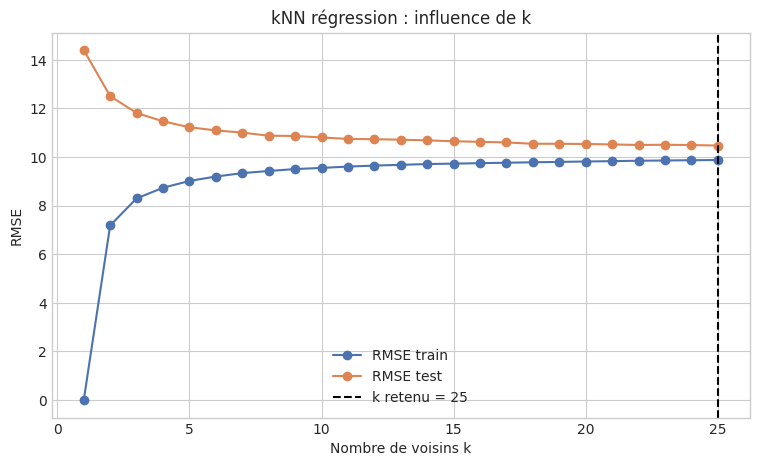

,k,rmse_train,rmse_test,r2_test
0,1,0.000000,14.402569,0.347785
1,2,7.186905,12.508381,0.508059
2,3,8.299142,11.814945,0.561091
3,4,8.737259,11.471404,0.586245
4,5,9.016137,11.228146,0.603606


In [20]:
knn_reg_rows = []
for k in range(1, 26):
    model = KNeighborsRegressor(n_neighbors=k, metric='euclidean')
    model.fit(Xr_train, yr_train)
    knn_reg_rows.append({
        'k': k,
        'rmse_train': mean_squared_error(yr_train, model.predict(Xr_train)) ** 0.5,
        'rmse_test': mean_squared_error(yr_test, model.predict(Xr_test)) ** 0.5,
        'r2_test': r2_score(yr_test, model.predict(Xr_test)),
    })

knn_reg_df = pd.DataFrame(knn_reg_rows)
best_k_reg = int(knn_reg_df.loc[knn_reg_df['rmse_test'].idxmin(), 'k'])

plt.figure(figsize=(9, 5))
plt.plot(knn_reg_df['k'], knn_reg_df['rmse_train'], marker='o', label='RMSE train')
plt.plot(knn_reg_df['k'], knn_reg_df['rmse_test'], marker='o', label='RMSE test')
plt.axvline(best_k_reg, color='black', linestyle='--', label=f'k retenu = {best_k_reg}')
plt.xlabel('Nombre de voisins k')
plt.ylabel('RMSE')
plt.title('kNN régression : influence de k')
plt.legend()
plt.show()

knn_reg_df.head()

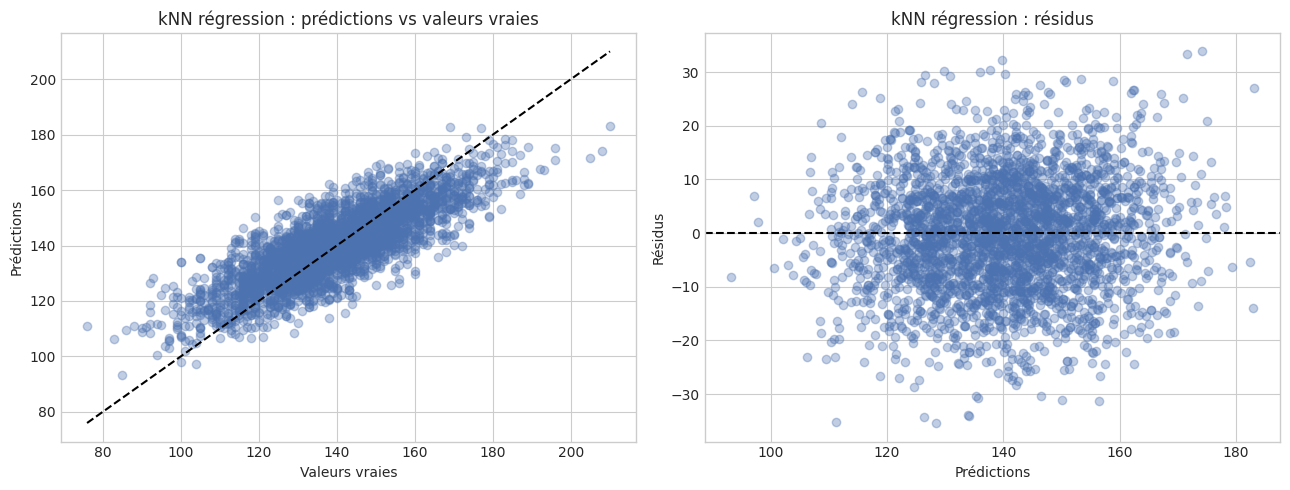

k retenu : 25
RMSE test : 10.475
MAE test : 8.344
R2 test : 0.655


In [21]:
knn_reg_final = KNeighborsRegressor(n_neighbors=best_k_reg, metric='euclidean')
knn_reg_final.fit(Xr_train, yr_train)
knn_reg_pred = knn_reg_final.predict(Xr_test)
knn_reg_resid = yr_test - knn_reg_pred

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(yr_test, knn_reg_pred, alpha=0.35)
axes[0].plot([yr_test.min(), yr_test.max()], [yr_test.min(), yr_test.max()], color='black', linestyle='--')
axes[0].set_title('kNN régression : prédictions vs valeurs vraies')
axes[0].set_xlabel('Valeurs vraies')
axes[0].set_ylabel('Prédictions')

axes[1].scatter(knn_reg_pred, knn_reg_resid, alpha=0.35)
axes[1].axhline(0, color='black', linestyle='--')
axes[1].set_title('kNN régression : résidus')
axes[1].set_xlabel('Prédictions')
axes[1].set_ylabel('Résidus')

plt.tight_layout()
plt.show()

print('k retenu :', best_k_reg)
print('RMSE test :', round(mean_squared_error(yr_test, knn_reg_pred) ** 0.5, 3))
print('MAE test :', round(mean_absolute_error(yr_test, knn_reg_pred), 3))
print('R2 test :', round(r2_score(yr_test, knn_reg_pred), 4))

In [22]:
Xr_train_sub, _, yr_train_sub, _ = train_test_split(
    Xr_train,
    yr_train,
    train_size=4000,
    random_state=11,
)

Xr_sub_fit, Xr_sub_val, yr_sub_fit, yr_sub_val = train_test_split(
    Xr_train_sub,
    yr_train_sub,
    test_size=0.25,
    random_state=11,
)

scaler_svr = StandardScaler().fit(Xr_sub_fit)
Xr_sub_fit_s = scaler_svr.transform(Xr_sub_fit)
Xr_sub_val_s = scaler_svr.transform(Xr_sub_val)
Xr_test_svr_s = scaler_svr.transform(Xr_test)

svr_rows = []
svr_configs = [
    ('linear', {'C': 0.5, 'epsilon': 1}),
    ('linear', {'C': 1, 'epsilon': 1}),
    ('linear', {'C': 5, 'epsilon': 1}),
    ('rbf', {'C': 1, 'epsilon': 1, 'gamma': 'scale'}),
    ('rbf', {'C': 5, 'epsilon': 1, 'gamma': 'scale'}),
    ('rbf', {'C': 5, 'epsilon': 2, 'gamma': 'scale'}),
    ('rbf', {'C': 5, 'epsilon': 1, 'gamma': 0.1}),
]

for kernel, params in svr_configs:
    model = SVR(kernel=kernel, **params)
    model.fit(Xr_sub_fit_s, yr_sub_fit)
    pred_fit = model.predict(Xr_sub_fit_s)
    pred_val = model.predict(Xr_sub_val_s)
    svr_rows.append({
        'kernel': kernel,
        'parametres': params,
        'rmse_fit': round(mean_squared_error(yr_sub_fit, pred_fit) ** 0.5, 3),
        'rmse_validation': round(mean_squared_error(yr_sub_val, pred_val) ** 0.5, 3),
        'r2_validation': round(r2_score(yr_sub_val, pred_val), 4),
    })

svr_df = pd.DataFrame(svr_rows).sort_values('rmse_validation')
svr_df

,kernel,parametres,rmse_fit,rmse_validation,r2_validation
0,linear,"{'C': 0.5, 'epsilon': 1}",9.850,9.781,0.6994
2,linear,"{'C': 5, 'epsilon': 1}",9.848,9.785,0.6991
1,linear,"{'C': 1, 'epsilon': 1}",9.848,9.786,0.6990
5,rbf,"{'C': 5, 'epsilon': 2, 'gamma': 'scale'}",9.498,10.321,0.6652
4,rbf,"{'C': 5, 'epsilon': 1, 'gamma': 'scale'}",9.496,10.350,0.6634
6,rbf,"{'C': 5, 'epsilon': 1, 'gamma': 0.1}",9.319,10.757,0.6364
3,rbf,"{'C': 1, 'epsilon': 1, 'gamma': 'scale'}",10.834,10.758,0.6363


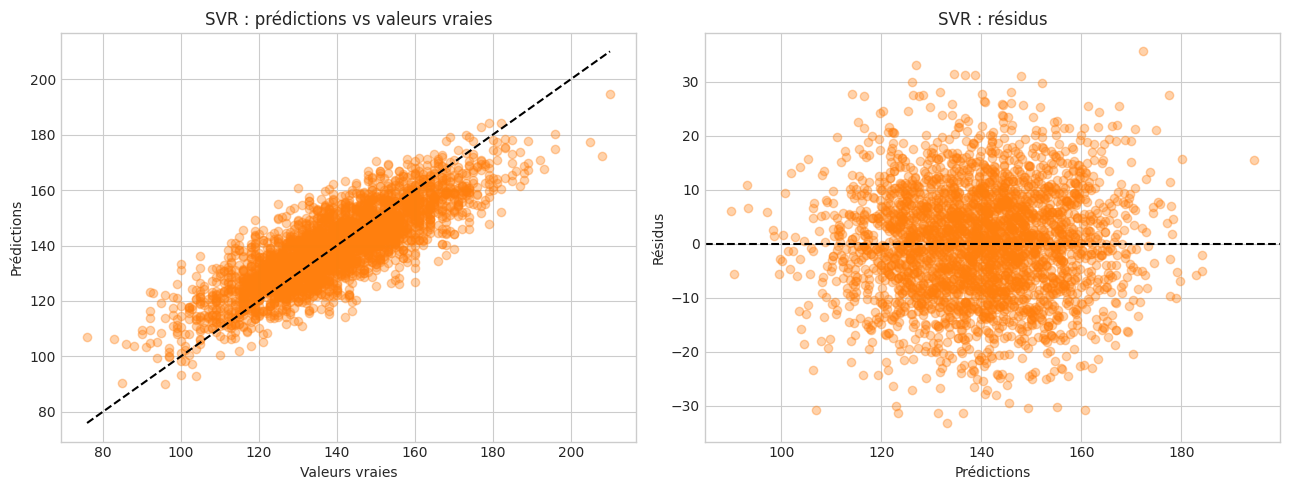

Meilleure configuration SVR : {'kernel': 'linear', 'C': 0.5, 'epsilon': 1}
RMSE test : 10.174
MAE test : 8.079
R2 test : 0.6745


In [23]:
best_svr = svr_df.iloc[0]
best_kernel = best_svr['kernel']
best_params = best_svr['parametres']

svr_final = SVR(kernel=best_kernel, **best_params)
svr_final.fit(Xr_sub_fit_s, yr_sub_fit)
svr_pred = svr_final.predict(Xr_test_svr_s)
svr_resid = yr_test - svr_pred

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(yr_test, svr_pred, alpha=0.35, color='tab:orange')
axes[0].plot([yr_test.min(), yr_test.max()], [yr_test.min(), yr_test.max()], color='black', linestyle='--')
axes[0].set_title('SVR : prédictions vs valeurs vraies')
axes[0].set_xlabel('Valeurs vraies')
axes[0].set_ylabel('Prédictions')

axes[1].scatter(svr_pred, svr_resid, alpha=0.35, color='tab:orange')
axes[1].axhline(0, color='black', linestyle='--')
axes[1].set_title('SVR : résidus')
axes[1].set_xlabel('Prédictions')
axes[1].set_ylabel('Résidus')

plt.tight_layout()
plt.show()

print('Meilleure configuration SVR :', {'kernel': best_kernel, **best_params})
print('RMSE test :', round(mean_squared_error(yr_test, svr_pred) ** 0.5, 3))
print('MAE test :', round(mean_absolute_error(yr_test, svr_pred), 3))
print('R2 test :', round(r2_score(yr_test, svr_pred), 4))

### Lecture des résultats en régression

Pour le kNN de régression, la courbe RMSE met en évidence le même compromis biais / variance qu'en classification :
- petit `k` : ajustement très local, sensible au bruit ;
- grand `k` : prédiction plus lissée.

Pour le SVR, le rôle des hyperparamètres est cohérent avec le cours :
- `C` contrôle le poids accordé aux écarts hors tube ;
- `epsilon` règle la largeur du tube d'insensibilité ;
- un noyau `rbf` peut apporter plus de flexibilité, mais avec un risque d'ajustement trop spécifique si `gamma` est trop grand.

Sur ces données, le **SVR linéaire** reste souvent très compétitif. Cela suggère que, pour la prédiction de `Cholesterol_LDL`, une relation globalement structurée suffit déjà à capturer une bonne partie du signal.

## 7. Comparaison globale

On compare maintenant les approches principales en distinguant bien classification et régression. Les résultats numériques ne suffisent pas seuls : il faut aussi tenir compte du coût de calcul, de la stabilité, de la sensibilité au scaling et de la philosophie du modèle.

In [24]:
classification_results = pd.DataFrame([
    {
        'Modèle': 'kNN classification',
        'Score train': round(knn_class_final.score(Xc_train_scaled, yc_train), 4),
        'Score test': round(knn_class_final.score(Xc_test_scaled, yc_test), 4),
        'Prétraitement': 'Scaling indispensable',
        'Interprétabilité': 'Locale, mais pas de modèle explicite',
        'Capacité non linéaire': 'Oui',
        'Limite principale': 'Sensibilité à la dimension et au choix de k',
    },
    {
        'Modèle': 'SVM linéaire',
        'Score train': round(svm_linear_final.score(Xc_sub_fit_s, yc_sub_fit), 4),
        'Score test': round(svm_linear_final.score(Xc_test_svm_s, yc_test), 4),
        'Prétraitement': 'Scaling très recommandé',
        'Interprétabilité': 'Géométrique, via hyperplan et supports',
        'Capacité non linéaire': 'Non',
        'Limite principale': 'Peut manquer de flexibilité si la frontière est très non linéaire',
    },
])
classification_results

,Modèle,Score train,Score test,Prétraitement,Interprétabilité,Capacité non linéaire,Limite principale
0,kNN classification,0.7435,0.7333,Scaling indispensable,"Locale, mais pas de modèle explicite",Oui,Sensibilité à la dimension et au choix de k
1,SVM linéaire,0.7323,0.7487,Scaling très recommandé,"Géométrique, via hyperplan et supports",Non,Peut manquer de flexibilité si la frontière es...


In [25]:
regression_results = pd.DataFrame([
    {
        'Modèle': 'kNN régression',
        'RMSE test': round(mean_squared_error(yr_test, knn_reg_pred) ** 0.5, 3),
        'MAE test': round(mean_absolute_error(yr_test, knn_reg_pred), 3),
        'R2 test': round(r2_score(yr_test, knn_reg_pred), 4),
        'Prétraitement': 'Souvent utile, mais effet parfois nuancé',
        'Interprétabilité': 'Locale, intuitive mais non globale',
        'Capacité non linéaire': 'Oui',
        'Limite principale': 'Coût prédictif et sensibilité au voisinage',
    },
    {
        'Modèle': 'SVR',
        'RMSE test': round(mean_squared_error(yr_test, svr_pred) ** 0.5, 3),
        'MAE test': round(mean_absolute_error(yr_test, svr_pred), 3),
        'R2 test': round(r2_score(yr_test, svr_pred), 4),
        'Prétraitement': 'Scaling fortement recommandé',
        'Interprétabilité': 'Moins directe, mais lecture via C/epsilon/kernel',
        'Capacité non linéaire': 'Oui avec noyau',
        'Limite principale': 'Réglage des hyperparamètres plus délicat',
    },
])
regression_results

,Modèle,RMSE test,MAE test,R2 test,Prétraitement,Interprétabilité,Capacité non linéaire,Limite principale
0,kNN régression,10.475,8.344,0.6550,"Souvent utile, mais effet parfois nuancé","Locale, intuitive mais non globale",Oui,Coût prédictif et sensibilité au voisinage
1,SVR,10.174,8.079,0.6745,Scaling fortement recommandé,"Moins directe, mais lecture via C/epsilon/kernel",Oui avec noyau,Réglage des hyperparamètres plus délicat


### Analyse comparative

Les expériences mettent bien en évidence deux philosophies :
- **kNN** est une méthode locale, centrée sur la proximité entre observations ;
- **SVM / SVR** sont des méthodes globales, fondées sur une géométrie de séparation ou de régularisation.

En classification, le kNN devient très compétitif après normalisation, mais son comportement dépend fortement de `k`. Le SVM linéaire apparaît plus stable, avec une interprétation géométrique claire par la marge et les vecteurs supports.

En régression, le kNN reste simple et lisible, mais peut être sensible au bruit local. Le SVR offre un cadre plus régularisé, avec un contrôle fin via `C`, `epsilon` et le noyau. En contrepartie, il demande davantage de réglages.

On retrouve donc des messages très proches du cours :
- importance de la **validation** pour choisir les hyperparamètres ;
- importance du **scaling** pour les méthodes géométriques et à distance ;
- nécessité de raisonner en termes de **biais / variance** plutôt qu'en ne regardant qu'un score brut.

## 8. Conclusion

Ce notebook montre bien que `kNN`, `SVM` et `SVR` répondent à des logiques théoriques différentes, mais complémentaires.

Le **kNN** est une méthode très intuitive, non paramétrique, fondée sur le voisinage local. Sa force est sa simplicité ; ses faiblesses sont sa sensibilité au bruit, à la dimension et au choix de `k`. Les expériences confirment bien le compromis biais / variance vu en cours : petit `k` sur-ajuste, grand `k` lisse davantage.

Les **SVM** reposent au contraire sur une logique géométrique globale. La maximisation de la marge, la régularisation via `C` et l'usage éventuel des noyaux fournissent un cadre souvent robuste pour la classification. Les expériences montrent qu'un modèle linéaire bien réglé peut déjà généraliser correctement, tandis que des noyaux plus flexibles peuvent sur-ajuster si l'on pousse trop la complexité.

Le **SVR** transpose cette logique à la régression via le tube `epsilon`. Il permet de contrôler de façon élégante le compromis entre précision d'ajustement et régularité de la fonction prédite. Sur ce jeu de données, il fournit une alternative crédible au kNN de régression, avec une interprétation théorique plus directement reliée à la régularisation.

Au final, les résultats confirment plusieurs idées essentielles des polys :
- la **normalisation** est souvent déterminante ;
- le choix des **hyperparamètres** est central ;
- les performances doivent toujours être reliées à la **généralisation**, pas seulement à l'erreur d'apprentissage ;
- la souplesse d'un modèle doit être pensée comme un compromis entre **biais**, **variance** et **coût computationnel**.

Ce type d'analyse est donc moins une recherche du modèle "magique" qu'un travail de comparaison raisonnée entre méthodes locales et méthodes à marge.